In [604]:
import sqlite3
import pandas as pd

In [605]:
conn = sqlite3.connect("../data/raw/eicu_v2_0_1.sqlite3"
)

In [606]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name;
    """,
    conn
)

tables

,name
0,admissiondrug
1,admissiondx
2,allergy
3,apacheapsvar
4,apachepatientresult
5,apachepredvar
6,careplancareprovider
7,careplaneol
8,careplangeneral
9,careplangoal


In [607]:
pd.read_sql_query(
    "PRAGMA table_info(patient);",
    conn
)

,cid,name,type,notnull,dflt_value,pk
0,0,patientunitstayid,INT,0,None,0
1,1,patienthealthsystemstayid,INT,0,None,0
2,2,gender,VARCHAR(25),0,None,0
3,3,age,VARCHAR(10),0,None,0
4,4,ethnicity,VARCHAR(50),0,None,0
5,5,hospitalid,INT,0,None,0
6,6,wardid,INT,0,None,0
7,7,apacheadmissiondx,VARCHAR(1000),0,None,0
8,8,admissionheight,"NUMERIC(10,2)",0,None,0
9,9,hospitaladmittime24,VARCHAR(8),0,None,0


In [608]:
patient_columns = pd.read_sql_query(
    "PRAGMA table_info(patient);",
    conn
)

patient_columns[["name", "type"]]

,name,type
0,patientunitstayid,INT
1,patienthealthsystemstayid,INT
2,gender,VARCHAR(25)
3,age,VARCHAR(10)
4,ethnicity,VARCHAR(50)
5,hospitalid,INT
6,wardid,INT
7,apacheadmissiondx,VARCHAR(1000)
8,admissionheight,"NUMERIC(10,2)"
9,hospitaladmittime24,VARCHAR(8)


In [609]:
patient_columns["name"].tolist()

['patientunitstayid',
 'patienthealthsystemstayid',
 'gender',
 'age',
 'ethnicity',
 'hospitalid',
 'wardid',
 'apacheadmissiondx',
 'admissionheight',
 'hospitaladmittime24',
 'hospitaladmitoffset',
 'hospitaladmitsource',
 'hospitaldischargeyear',
 'hospitaldischargetime24',
 'hospitaldischargeoffset',
 'hospitaldischargelocation',
 'hospitaldischargestatus',
 'unittype',
 'unitadmittime24',
 'unitadmitsource',
 'unitvisitnumber',
 'unitstaytype',
 'admissionweight',
 'dischargeweight',
 'unitdischargetime24',
 'unitdischargeoffset',
 'unitdischargelocation',
 'unitdischargestatus',
 'uniquepid']

In [610]:
patient_sample = pd.read_sql_query(
    """
    SELECT *
    FROM patient
    LIMIT 5;
    """,
    conn
)

patient_sample

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitadmitsource,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid
0,141764,129391,Female,87,Caucasian,59,91,,157.5,23:36:00,...,ICU to SDU,2,stepdown/other,,,18:58:00,344,Home,Alive,002-1039
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",157.5,23:36:00,...,Emergency Department,1,admit,46.5,45,13:14:00,2250,Step-Down Unit (SDU),Alive,002-1039
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",167.0,20:46:00,...,Operating Room,1,admit,77.5,79.4,10:00:00,793,Floor,Alive,002-12289
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",172.7,01:44:00,...,Emergency Department,1,admit,60.3,60.7,20:48:00,1121,Other External,Alive,002-1116
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",177.8,23:48:00,...,Operating Room,1,admit,91.7,93.1,22:47:00,1369,Floor,Alive,002-12243


In [611]:
patient_sample.T

,0,1,2,3,4
patientunitstayid,141764,141765,143870,144815,145427
patienthealthsystemstayid,129391,129391,131022,131736,132209
gender,Female,Female,Male,Female,Male
age,87,87,76,34,61
ethnicity,Caucasian,Caucasian,Caucasian,Caucasian,Caucasian
hospitalid,59,59,68,56,68
wardid,91,91,103,82,103
apacheadmissiondx,,"Rhythm disturbance (atrial, supraventricular)","Endarterectomy, carotid","Overdose, other toxin, poison or drug","GI perforation/rupture, surgery for"
admissionheight,157.5,157.5,167.0,172.7,177.8
hospitaladmittime24,23:36:00,23:36:00,20:46:00,01:44:00,23:48:00


In [612]:
patient_core = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        patienthealthsystemstayid,
        gender,
        age,
        ethnicity,
        hospitalid,
        wardid,
        apacheadmissiondx,
        hospitaladmitsource,
        hospitaldischargestatus,
        hospitaldischargelocation,
        unittype,
        unitadmitsource,
        unitstaytype,
        unitdischargestatus,
        unitdischargelocation,
        unitdischargeoffset
    FROM patient;
    """,
    conn
)

patient_core.head()

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,hospitaladmitsource,hospitaldischargestatus,hospitaldischargelocation,unittype,unitadmitsource,unitstaytype,unitdischargestatus,unitdischargelocation,unitdischargeoffset
0,141764,129391,Female,87,Caucasian,59,91,,,Alive,Home,Med-Surg ICU,ICU to SDU,stepdown/other,Alive,Home,344
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",,Alive,Home,Med-Surg ICU,Emergency Department,admit,Alive,Step-Down Unit (SDU),2250
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",Operating Room,Alive,Home,SICU,Operating Room,admit,Alive,Floor,793
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",Emergency Department,Alive,Other Hospital,Med-Surg ICU,Emergency Department,admit,Alive,Other External,1121
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",Emergency Department,Alive,Home,SICU,Operating Room,admit,Alive,Floor,1369


In [613]:
patient_core.shape

(2520, 17)

In [614]:
patient_core.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   patientunitstayid          2520 non-null   int64
 1   patienthealthsystemstayid  2520 non-null   int64
 2   gender                     2520 non-null   str  
 3   age                        2520 non-null   str  
 4   ethnicity                  2520 non-null   str  
 5   hospitalid                 2520 non-null   int64
 6   wardid                     2520 non-null   int64
 7   apacheadmissiondx          2520 non-null   str  
 8   hospitaladmitsource        2520 non-null   str  
 9   hospitaldischargestatus    2520 non-null   str  
 10  hospitaldischargelocation  2520 non-null   str  
 11  unittype                   2520 non-null   str  
 12  unitadmitsource            2520 non-null   str  
 13  unitstaytype               2520 non-null   str  
 14  unitdischargestatus        2520 non

In [615]:
patient_core.isna().sum()

patientunitstayid            0
patienthealthsystemstayid    0
gender                       0
age                          0
ethnicity                    0
hospitalid                   0
wardid                       0
apacheadmissiondx            0
hospitaladmitsource          0
hospitaldischargestatus      0
hospitaldischargelocation    0
unittype                     0
unitadmitsource              0
unitstaytype                 0
unitdischargestatus          0
unitdischargelocation        0
unitdischargeoffset          0
dtype: int64

In [616]:
patient_core["los_days"] = (
    patient_core["unitdischargeoffset"] / 1440
)

In [617]:
patient_core[
    ["patientunitstayid", "unitdischargeoffset", "los_days"]
].head()

,patientunitstayid,unitdischargeoffset,los_days
0,141764,344,0.238889
1,141765,2250,1.562500
2,143870,793,0.550694
3,144815,1121,0.778472
4,145427,1369,0.950694


In [618]:
patient_core["los_days"].describe()

count    2520.000000
mean        2.419497
std         3.456362
min         0.000000
25%         0.790104
50%         1.472222
75%         2.776736
max        46.179861
Name: los_days, dtype: float64

<Axes: >

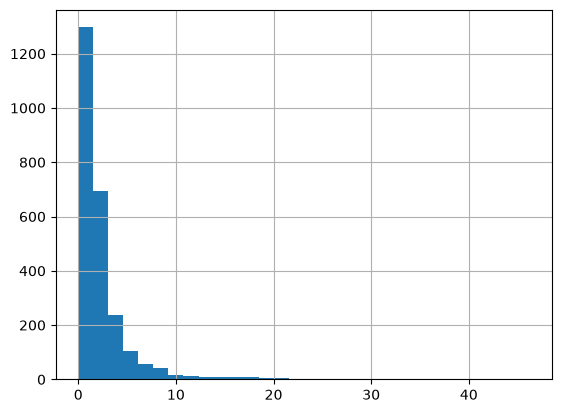

In [619]:
patient_core["los_days"].hist(bins=30)

In [620]:
patient_core["unitdischargestatus"].value_counts(dropna=False)

unitdischargestatus
Alive      2392
Expired     126
              2
Name: count, dtype: int64

In [621]:
patient_core["icu_death"] = (
    patient_core["unitdischargestatus"]
    .eq("Expired")
    .astype(int)
)

In [622]:
patient_core["icu_death"].value_counts()

icu_death
0    2394
1     126
Name: count, dtype: int64

In [623]:
patient_core["gender"].value_counts(dropna=False)

gender
Male      1508
Female    1008
             4
Name: count, dtype: int64

In [624]:
patient_core["age"].value_counts().head(20)

age
> 89    98
78      76
68      70
67      70
79      66
76      64
77      62
63      58
73      58
74      58
64      56
75      54
82      54
69      53
70      53
66      52
57      52
55      51
62      51
71      50
Name: count, dtype: int64

In [625]:
patient_core["unittype"].value_counts()

unittype
Med-Surg ICU    1898
MICU             142
Cardiac ICU      133
SICU              83
CCU-CTICU         82
Neuro ICU         65
CSICU             65
CTICU             52
Name: count, dtype: int64

In [626]:
patient_core["apacheadmissiondx"].value_counts().head(20)

apacheadmissiondx
                                                                                                                                299
Sepsis, pulmonary                                                                                                               121
Diabetic ketoacidosis                                                                                                           105
CHF, congestive heart failure                                                                                                   102
Rhythm disturbance (atrial, supraventricular)                                                                                    79
Pneumonia, bacterial                                                                                                             68
Emphysema/bronchitis                                                                                                             65
Infarction, acute myocardial (MI)                         

In [627]:
patient_core["unitdischargestatus"].value_counts(dropna=False)

unitdischargestatus
Alive      2392
Expired     126
              2
Name: count, dtype: int64

In [628]:
apache_columns = pd.read_sql_query(
    "PRAGMA table_info(apachePatientResult);",
    conn
)

apache_columns[["name", "type"]]

,name,type
0,apachepatientresultsid,INT
1,patientunitstayid,INT
2,physicianspeciality,VARCHAR(50)
3,physicianinterventioncategory,VARCHAR(50)
4,acutephysiologyscore,INT
5,apachescore,INT
6,apacheversion,VARCHAR(5)
7,predictedicumortality,VARCHAR(50)
8,actualicumortality,VARCHAR(50)
9,predictediculos,DOUBLE PRECISION


In [629]:
apache_columns["name"].tolist()

['apachepatientresultsid',
 'patientunitstayid',
 'physicianspeciality',
 'physicianinterventioncategory',
 'acutephysiologyscore',
 'apachescore',
 'apacheversion',
 'predictedicumortality',
 'actualicumortality',
 'predictediculos',
 'actualiculos',
 'predictedhospitalmortality',
 'actualhospitalmortality',
 'predictedhospitallos',
 'actualhospitallos',
 'preopmi',
 'preopcardiaccath',
 'ptcawithin24h',
 'unabridgedunitlos',
 'unabridgedhosplos',
 'actualventdays',
 'predventdays',
 'unabridgedactualventdays']

In [630]:
apache = pd.read_sql_query(
    """
    SELECT *
    FROM apachePatientResult;
    """,
    conn
)

In [631]:
icu = patient_core.merge(
    apache,
    on="patientunitstayid",
    how="left"
)

In [632]:
diagnosis_columns = pd.read_sql_query(
    "PRAGMA table_info(diagnosis);",
    conn
)

diagnosis_columns[["name", "type"]]

,name,type
0,diagnosisid,INT
1,patientunitstayid,INT
2,activeupondischarge,VARCHAR(64)
3,diagnosisoffset,INT
4,diagnosisstring,VARCHAR(200)
5,icd9code,VARCHAR(100)
6,diagnosispriority,VARCHAR(10)


In [633]:
diagnosis_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        COUNT(*) AS n_diagnoses
    FROM diagnosis
    GROUP BY patientunitstayid;
    """,
    conn
)

In [634]:
diagnosis_summary.head(10)

,patientunitstayid,n_diagnoses
0,143870,3
1,145427,8
2,151179,18
3,151867,2
4,151900,31
5,152954,15
6,153972,21
7,155961,4
8,156308,5
9,157016,3


In [635]:
diagnosis_summary.shape

(2155, 2)

In [636]:
diagnosis_summary["patientunitstayid"].duplicated().sum()

np.int64(0)

In [637]:
resp_columns = pd.read_sql_query(
    "PRAGMA table_info(respiratoryCare);",
    conn
)

resp_columns[["name", "type"]]

,name,type
0,RESPCAREID,INT
1,PATIENTUNITSTAYID,INT
2,RESPCARESTATUSOFFSET,INT
3,CURRENTHISTORYSEQNUM,INT
4,AIRWAYTYPE,VARCHAR(30)
5,AIRWAYSIZE,VARCHAR(10)
6,AIRWAYPOSITION,VARCHAR(32)
7,CUFFPRESSURE,"NUMERIC(5,1)"
8,VENTSTARTOFFSET,INT
9,VENTENDOFFSET,INT


In [638]:
resp_columns["name"].tolist()

['RESPCAREID',
 'PATIENTUNITSTAYID',
 'RESPCARESTATUSOFFSET',
 'CURRENTHISTORYSEQNUM',
 'AIRWAYTYPE',
 'AIRWAYSIZE',
 'AIRWAYPOSITION',
 'CUFFPRESSURE',
 'VENTSTARTOFFSET',
 'VENTENDOFFSET',
 'PRIORVENTSTARTOFFSET',
 'PRIORVENTENDOFFSET',
 'APNEAPARAMS',
 'LOWEXHMVLIMIT',
 'HIEXHMVLIMIT',
 'LOWEXHTVLIMIT',
 'HIPEAKPRESLIMIT',
 'LOWPEAKPRESLIMIT',
 'HIRESPRATELIMIT',
 'LOWRESPRATELIMIT',
 'SIGHPRESLIMIT',
 'LOWIRONOXLIMIT',
 'HIGHIRONOXLIMIT',
 'MEANAIRWAYPRESLIMIT',
 'PEEPLIMIT',
 'CPAPLIMIT',
 'SETAPNEAINTERVAL',
 'SETAPNEATV',
 'SETAPNEAIPPEEPHIGH',
 'SETAPNEARR',
 'SETAPNEAPEAKFLOW',
 'SETAPNEAINSPTIME',
 'SETAPNEAIE',
 'SETAPNEAFIO2']

In [639]:
resp_sample = pd.read_sql_query(
    """
    SELECT *
    FROM respiratoryCare
    LIMIT 10;
    """,
    conn
)

resp_sample.T

,0,1,2,3,4,5,6,7,8,9
RESPCAREID,564013,564012,545261,545262,550472,550471,545434,555630,554522,554521
PATIENTUNITSTAYID,147784,147784,165840,165840,187150,187150,197617,197619,198627,198627
RESPCARESTATUSOFFSET,1188,-61,-63,73,7293,-222,6644,670,5580,1047
CURRENTHISTORYSEQNUM,2,1,1,2,2,1,2,1,2,1
AIRWAYTYPE,,,,,,,,,,
AIRWAYSIZE,,,,,,,,,,
AIRWAYPOSITION,,,,,,,,,,
CUFFPRESSURE,,,,,,,,,,
VENTSTARTOFFSET,0,-361,-363,0,0,-522,0,310,0,-290
VENTENDOFFSET,0,0,0,0,0,0,0,0,0,0


In [640]:
treatment_columns = pd.read_sql_query(
    "PRAGMA table_info(treatment);",
    conn
)

treatment_columns[["name", "type"]]

,name,type
0,treatmentid,INT
1,patientunitstayid,INT
2,treatmentoffset,INT
3,treatmentstring,VARCHAR(200)
4,activeupondischarge,VARCHAR(10)


In [641]:
treatment_columns["name"].tolist()

['treatmentid',
 'patientunitstayid',
 'treatmentoffset',
 'treatmentstring',
 'activeupondischarge']

In [642]:
treatment_sample = pd.read_sql_query(
    """
    SELECT *
    FROM treatment
    LIMIT 20;
    """,
    conn
)

treatment_sample

,treatmentid,patientunitstayid,treatmentoffset,treatmentstring,activeupondischarge
0,9579899,242895,838,cardiovascular|arrhythmias|anticoagulant admin...,False
1,8788989,242895,512,cardiovascular|consultations|Cardiology consul...,False
2,10293108,242895,838,cardiovascular|non-operative procedures|extern...,False
3,9017080,242895,70,pulmonary|vascular disorders|VTE prophylaxis|l...,False
4,9853526,242895,70,cardiovascular|consultations|Cardiology consul...,False
5,10361067,242895,1434,pulmonary|medications|bronchodilator|inhaled,True
6,8725224,242895,838,cardiovascular|consultations|Cardiology consul...,False
7,8518378,242895,512,pulmonary|medications|bronchodilator|inhaled,False
8,9102158,242895,1434,cardiovascular|non-operative procedures|diagno...,True
9,9091773,242895,838,pulmonary|medications|bronchodilator|inhaled,False


In [643]:
med_columns = pd.read_sql_query(
    "PRAGMA table_info(medication);",
    conn
)

med_columns[["name", "type"]]

,name,type
0,medicationid,INT
1,patientunitstayid,INT
2,drugorderoffset,INT
3,drugstartoffset,INT
4,drugivadmixture,VARCHAR(6)
5,drugordercancelled,VARCHAR(6)
6,drugname,VARCHAR(220)
7,drughiclseqno,INT
8,dosage,VARCHAR(60)
9,routeadmin,VARCHAR(120)


In [644]:
med_sample = pd.read_sql_query(
    """
    SELECT *
    FROM medication
    LIMIT 10;
    """,
    conn
)

med_sample.T

,0,1,2,3,4,5,6,7,8,9
medicationid,7278819,9726266,10293599,10871534,10128716,8580224,7019364,10899992,8855227,9587719
patientunitstayid,141765,141765,141765,141765,141765,143870,143870,143870,143870,143870
drugorderoffset,134,1,115,114,115,17,4,4,16,16
drugstartoffset,1396,-188,856,316,856,1033,-164,-420,1033,133
drugivadmixture,No,No,No,No,No,No,No,No,No,No
drugordercancelled,No,No,No,No,No,No,No,No,No,No
drugname,WARFARIN SODIUM 5 MG PO TABS,5 ML VIAL : DILTIAZEM HCL 25 MG/5ML IV SOLN,ASPIRIN EC 81 MG PO TBEC,DILTIAZEM HCL 30 MG PO TABS,LISINOPRIL 5 MG PO TABS,ASPIRIN EC 81 MG PO TBEC,1 ML - DIPHENHYDRAMINE HCL 50 MG/ML IJ SOLN,METOPROLOL TARTRATE 25 MG PO TABS,CLOPIDOGREL BISULFATE 75 MG PO TABS,
drughiclseqno,2812,182,1820,182,132,1820,4480,2102,17539,2104
dosage,5 3,15 3,81 3,30 3,5 3,81 3,25 3,25 3,75 3,25 3
routeadmin,PO,IV,PO,PO,PO,PO,IV,PO,PO,PO


In [645]:
medication_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        COUNT(*) AS n_medication_records
    FROM medication
    GROUP BY patientunitstayid;
    """,
    conn
)

In [646]:
medication_summary.head(10)

,patientunitstayid,n_medication_records
0,141764,2
1,141765,14
2,143870,40
3,144815,5
4,145427,40
5,147307,21
6,147784,56
7,148611,9
8,149432,4
9,149433,4


In [647]:
medication_summary["patientunitstayid"].duplicated().sum()

np.int64(0)

In [648]:
lab_columns = pd.read_sql_query(
    "PRAGMA table_info(lab);",
    conn
)

lab_columns[["name", "type"]]

,name,type
0,labid,INT
1,patientunitstayid,INT
2,labresultoffset,INT
3,labtypeid,"NUMERIC(3,0)"
4,labname,VARCHAR(256)
5,labresult,"NUMERIC(11,4)"
6,labresulttext,VARCHAR(255)
7,labmeasurenamesystem,VARCHAR(255)
8,labmeasurenameinterface,VARCHAR(255)
9,labresultrevisedoffset,INT


In [649]:
lab_sample = pd.read_sql_query(
    """
    SELECT *
    FROM lab
    LIMIT 10;
    """,
    conn
)

lab_sample.T

,0,1,2,3,4,5,6,7,8,9
labid,437880563,437880572,437880560,437880570,437880571,435917188,437880567,435917185,437880566,435917183
patientunitstayid,1754323,1754323,1754323,1754323,1754323,1754323,1754323,1754323,1754323,1754323
labresultoffset,-647,-647,-647,-647,-647,-207,-647,-207,-647,-207
labtypeid,3,3,3,3,3,3,3,3,3,3
labname,Hct,platelets x 1000,RBC,-monos,MCHC,WBC x 1000,WBC x 1000,Hct,Hgb,MPV
labresult,38.3,181.0,4.86,8.7,30.4,14.3,5.4,32.5,11.6,8.2
labresulttext,38.3,181,4.86,8.7,30.4,14.3,5.4,32.5,11.6,8.2
labmeasurenamesystem,%,K/mcL,M/mcL,%,g/dL,K/mcL,K/mcL,%,g/dL,fL
labmeasurenameinterface,%,k/mm cu,m/mm cu,%,%,k/mm cu,k/mm cu,%,g/dL,fL
labresultrevisedoffset,-631,-631,-631,-631,-631,-175,-631,-175,-631,-175


In [650]:
lab_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        COUNT(*) AS n_lab_records
    FROM lab
    GROUP BY patientunitstayid;
    """,
    conn
)

In [651]:
lab_summary.head()

,patientunitstayid,n_lab_records
0,141765,72
1,143870,49
2,144815,74
3,145427,94
4,147306,10


In [652]:
lab_summary["patientunitstayid"].duplicated().sum()

np.int64(0)

In [653]:
icu_analytics = patient_core.copy()

In [654]:
icu_analytics.shape

(2520, 19)

In [655]:
icu_analytics = icu_analytics.merge(
    diagnosis_summary,
    on="patientunitstayid",
    how="left"
)

In [656]:
icu_analytics.shape

(2520, 20)

In [657]:
icu_analytics = icu_analytics.merge(
    lab_summary,
    on="patientunitstayid",
    how="left"
)

In [658]:
icu_analytics.shape

(2520, 21)

In [659]:
lab_summary.head()

,patientunitstayid,n_lab_records
0,141765,72
1,143870,49
2,144815,74
3,145427,94
4,147306,10


In [660]:
icu_analytics = icu_analytics.merge(
    lab_summary,
    on="patientunitstayid",
    how="left"
)

In [661]:
icu_analytics.shape

(2520, 22)

In [662]:
for col in count_columns:
    if col in icu_analytics.columns:
        print(f"✅ {col} existe")
    else:
        print(f"❌ {col} NÃO existe")

NameError: name 'count_columns' is not defined

In [ ]:
medication_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        COUNT(*) AS n_medication_records
    FROM medication
    GROUP BY patientunitstayid;
    """,
    conn
)

medication_summary.head()

,patientunitstayid,n_medication_records
0,141764,2
1,141765,14
2,143870,40
3,144815,5
4,145427,40


In [ ]:
medication_summary["patientunitstayid"].duplicated().sum()

np.int64(0)

In [ ]:
icu_analytics = icu_analytics.merge(
    medication_summary,
    on="patientunitstayid",
    how="left"
)

icu_analytics.shape

(2520, 23)

In [ ]:
lab_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        COUNT(*) AS n_lab_records
    FROM lab
    GROUP BY patientunitstayid;
    """,
    conn
)

lab_summary.head()

,patientunitstayid,n_lab_records
0,141765,72
1,143870,49
2,144815,74
3,145427,94
4,147306,10


In [ ]:
lab_summary["patientunitstayid"].duplicated().sum()

np.int64(0)

In [ ]:
icu_analytics = icu_analytics.merge(
    lab_summary,
    on="patientunitstayid",
    how="left"
)

icu_analytics.shape

(2520, 24)

In [ ]:
count_columns = [
    "n_diagnoses",
    "n_medication_records",
    "n_lab_records"
]

icu_analytics[count_columns] = (
    icu_analytics[count_columns]
    .fillna(0)
)

In [ ]:
icu_analytics[
    [
        "patientunitstayid",
        "n_diagnoses",
        "n_medication_records",
        "n_lab_records"
    ]
].head(10)

,patientunitstayid,n_diagnoses,n_medication_records,n_lab_records
0,141764,0.0,2.0,0.0
1,141765,0.0,14.0,72.0
2,143870,3.0,40.0,49.0
3,144815,0.0,5.0,74.0
4,145427,8.0,40.0,94.0
5,147306,0.0,0.0,10.0
6,147307,0.0,21.0,30.0
7,147784,0.0,56.0,139.0
8,148611,0.0,9.0,55.0
9,149432,0.0,4.0,19.0


In [ ]:
print("Shape:", icu_analytics.shape)

print(
    "IDs duplicados:",
    icu_analytics["patientunitstayid"].duplicated().sum()
)

Shape: (2520, 24)
IDs duplicados: 0


In [ ]:
icu_analytics.info()

<class 'pandas.DataFrame'>
RangeIndex: 2520 entries, 0 to 2519
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patientunitstayid          2520 non-null   int64  
 1   patienthealthsystemstayid  2520 non-null   int64  
 2   gender                     2520 non-null   str    
 3   age                        2520 non-null   str    
 4   ethnicity                  2520 non-null   str    
 5   hospitalid                 2520 non-null   int64  
 6   wardid                     2520 non-null   int64  
 7   apacheadmissiondx          2520 non-null   str    
 8   hospitaladmitsource        2520 non-null   str    
 9   hospitaldischargestatus    2520 non-null   str    
 10  hospitaldischargelocation  2520 non-null   str    
 11  unittype                   2520 non-null   str    
 12  unitadmitsource            2520 non-null   str    
 13  unitstaytype               2520 non-null   str    
 14  uni

In [ ]:
icu_analytics.isna().sum().sort_values(ascending=False)

n_lab_records_y              76
n_lab_records_x              76
patientunitstayid             0
patienthealthsystemstayid     0
ethnicity                     0
hospitalid                    0
gender                        0
age                           0
apacheadmissiondx             0
wardid                        0
hospitaladmitsource           0
hospitaldischargestatus       0
unitadmitsource               0
unitstaytype                  0
hospitaldischargelocation     0
unittype                      0
unitdischargelocation         0
unitdischargestatus           0
unitdischargeoffset           0
los_days                      0
n_diagnoses                   0
icu_death                     0
n_medication_records          0
n_lab_records                 0
dtype: int64

In [ ]:
icu_analytics.to_csv(
    "../data/processed/icu_analytics_v1.csv",
    index=False
)

In [ ]:
print(
    "Total ICU Stays:",
    icu_analytics["patientunitstayid"].nunique()
)

print(
    "Average LOS:",
    icu_analytics["los_days"].mean()
)

print(
    "ICU Mortality Rate:",
    icu_analytics["icu_death"].mean()
)

Total ICU Stays: 2520
Average LOS: 2.419496527777778
ICU Mortality Rate: 0.05


In [ ]:
print(
    "Total ICU Stays:",
    icu_analytics["patientunitstayid"].nunique()
)

Total ICU Stays: 2520


In [ ]:
print("TESTE")

TESTE


In [ ]:
apache_summary = pd.read_sql_query(
    """
    SELECT
        patientunitstayid,
        apachescore AS apache_score,
        predictedicumortality AS predicted_icu_mortality,
        predictediculos AS predicted_icu_los,
        actualventdays AS actual_vent_days,
        apacheversion AS apache_version
    FROM apachePatientResult
    WHERE apacheversion = 'IVa';
    """,
    conn
)

apache_summary.head()

,patientunitstayid,apache_score,predicted_icu_mortality,predicted_icu_los,actual_vent_days,apache_version
0,141765,47,0.01231145545549805,1.374807,,IVa
1,143870,60,1.5706796732545089E-2,3.021671,,IVa
2,144815,25,2.1330459623421791E-3,0.806311,,IVa
3,145427,37,7.5555085721478212E-3,3.503540,,IVa
4,147307,20,1.9315974648549681E-3,0.820676,,IVa


In [ ]:
print("Linhas:", apache_summary.shape[0])
print(
    "Duplicados:",
    apache_summary["patientunitstayid"].duplicated().sum()
)

Linhas: 1838
Duplicados: 0


In [ ]:
import numpy as np

apache_summary[
    [
        "apache_score",
        "predicted_icu_mortality",
        "predicted_icu_los",
        "actual_vent_days"
    ]
] = apache_summary[
    [
        "apache_score",
        "predicted_icu_mortality",
        "predicted_icu_los",
        "actual_vent_days"
    ]
].replace(-1, np.nan)

In [ ]:
apache_summary["actual_vent_days"] = pd.to_numeric(
    apache_summary["actual_vent_days"],
    errors="coerce"
)

In [ ]:
apache_summary["actual_vent_days"].dtype

dtype('float64')

In [ ]:
apache_summary["ventilation_status"] = np.select(
    [
        apache_summary["actual_vent_days"] > 0,
        apache_summary["actual_vent_days"] == 0
    ],
    [
        "Ventilated",
        "Not ventilated"
    ],
    default="Unknown"
)

In [ ]:
apache_summary[
    ["actual_vent_days", "ventilation_status"]
].head(20)

,actual_vent_days,ventilation_status
0,NaN,Unknown
1,NaN,Unknown
2,NaN,Unknown
3,NaN,Unknown
4,NaN,Unknown
5,1.0,Ventilated
6,NaN,Unknown
7,NaN,Unknown
8,NaN,Unknown
9,NaN,Unknown
